# Day 6 Exercise 2b - SOLVED + companion

The answer key for `Day6_Exercise_2b`, plus the reasoning around each step: diagrams, a Pydantic primer, thinking guides, a data visual, decision matrices, and the frameworks worth keeping.

- Runs top to bottom to **6 / 6**. Scoring is offline; no AWS credentials needed.
- Mermaid diagrams render on GitHub, nbviewer, or mermaid.live. The `show_graph()` cell also prints a Mermaid string from your actual wiring.
- Only TODO 6 needs `strands-agents` installed (building a graph makes no AWS call).

## The mental model

One pipeline, four destinations. Cheap rules run first; a model call is the fallback, not the default.

```mermaid
flowchart TD
    M[Customer message] --> H{Cheap heuristic sure?}
    H -->|yes, 0 model calls| EX[Extraction]
    H -->|no| LLM[LLM extractor]
    LLM --> EX
    EX --> R{decide_route}
    R -->|valid PNR and standard intent| W[write: happy path]
    R -->|missing or unclear| C[clarify: ask one question]
    R -->|non-standard intent| E[escalate: human]
    EX -. failure .-> E
```

The whole design optimises one number: model calls per request. Reason about it like this:

$$
\text{cost per request} = \sum_{p\,\in\,\text{paths}} P(p)\cdot n_{\text{calls}}(p)\cdot c_{\text{call}}
$$

Heuristics push $n_{\text{calls}}$ on the common path toward zero, and a deterministic escalation keeps the red-flag path cheap too. The model is your most expensive component; treat it that way.

Skeptic's question to hold onto: a heuristic wrong 2 percent of the time versus a model call right 99 percent but billed on every single message. Which one is actually cheaper at a million requests a day?

## Pydantic in five minutes

A `BaseModel` is a typed dict that validates itself.

- **Fields** are a type hint plus an optional `Field(...)`: `Field(default=None, ge=0.0, le=1.0, description="...")`.
- **`str, Enum`** gives a closed vocabulary. `intent: Intent` can only ever be one of the listed values, so a typo cannot leak downstream.
- **v2 methods you will use**: `model_dump()` (to dict), `model_dump_json()` (to JSON string), `model_validate_json(text)` (parse and validate). These replaced the v1 names `.dict()`, `.json()`, `.parse_raw()`.
- **Why it beats `json.loads`**: `structured_output` turns your model into a tool spec the model must fill, then validates the result. Add a `field_validator` and the SDK feeds validation errors back to the model to self-correct, so you write no retry loop.

Gotchas worth knowing:

- Enums coerce from their value string, so `intent="disruption"` becomes `Intent.DISRUPTION`.
- Unknown fields are ignored by default; a missing required field raises `ValidationError`.
- `ge` / `le` are range guards; use them for confidence, ratings, counts.

In [1]:
from enum import Enum
from typing import Optional
from pydantic import BaseModel, Field, ValidationError

class _Intent(str, Enum):
    DISRUPTION = "disruption"
    OTHER      = "other"

class _Demo(BaseModel):
    pnr: Optional[str] = Field(default=None)
    intent: _Intent = Field(default=_Intent.OTHER)
    confidence: float = Field(default=1.0, ge=0.0, le=1.0)

good = _Demo(pnr="JX48Q2", intent="disruption", confidence=0.9)   # str coerced to the enum
print("intent ->", good.intent, "| json ->", good.model_dump_json())

try:
    _Demo(confidence=1.7)     # out of range
except ValidationError as e:
    err = e.errors()[0]
    print("rejected ->", err["type"], "|", err["msg"])

intent -> _Intent.DISRUPTION | json -> {"pnr":"JX48Q2","intent":"disruption","confidence":0.9}
rejected -> less_than_equal | Input should be less than or equal to 1


## Scaffolding (given, pure Python, no AWS)

Same provided cell as the exercise. It defines the domain models, the intent hints, the mock graph state, and the visual helpers.

In [2]:
# ---- provided scaffolding. Pure Python, no AWS. ----
import re
from enum import Enum
from typing import Optional
from pydantic import BaseModel, Field, ValidationError

class Intent(str, Enum):
    BOOKING_STATUS = "booking_status"
    DISRUPTION     = "disruption"
    REBOOKING      = "rebooking"
    REFUND         = "refund"
    BAGGAGE        = "baggage"
    OTHER          = "other"

class Extraction(BaseModel):
    pnr: Optional[str] = Field(default=None)
    intent: Intent = Field(default=Intent.OTHER)
    confidence: float = Field(default=1.0, ge=0.0, le=1.0)
    ambiguity_reason: Optional[str] = Field(default=None)

class Route(str, Enum):
    WRITE    = "write"
    CLARIFY  = "clarify"
    ESCALATE = "escalate"

PNR_RE = re.compile(r"^[A-Z0-9]{6}$")
INTENT_HINTS = {
    Intent.DISRUPTION:     ("cancel", "cancelled", "delayed", "delay", "disrupt", "stranded"),
    Intent.REBOOKING:      ("rebook", "another flight", "next flight", "change my flight"),
    Intent.REFUND:         ("refund", "money back", "reimburse"),
    Intent.BAGGAGE:        ("baggage", "luggage", "suitcase"),
    Intent.BOOKING_STATUS: ("status", "confirmed", "is my flight"),
}
CANDIDATE = re.compile(r"\b[A-Z0-9]{6}\b")

def find_pnr(text):
    for tok in CANDIDATE.findall(text.upper()):
        if valid_pnr(tok):
            return tok
    return None

WIRING = []
ENTRY  = {"node": None}

def add_edge_viz(builder, src, dst, route):
    builder.add_edge(src, dst, condition=route_is(route))   # the real Strands call
    WIRING.append((src, dst, route.value))

def set_entry_viz(builder, node):
    builder.set_entry_point(node)
    ENTRY["node"] = node

class _MockNode:
    def __init__(self, text): self.result = text
class MockState:
    def __init__(self, extract_json): self.results = {"extract": _MockNode(extract_json)}

def _extraction_from_state(state):
    node = state.results.get("extract")
    if not node:
        return None
    try:
        return Extraction.model_validate_json(str(node.result))
    except Exception:
        return None

def dry_run(sample):
    state = MockState(sample.model_dump_json())
    fired = [r for r in (Route.WRITE, Route.CLARIFY, Route.ESCALATE) if route_is(r)(state)]
    branch = fired[0].value if len(fired) == 1 else ("NONE/MULTI " + str([f.value for f in fired]))
    print("  extract --> " + branch +
          "   (intent=" + sample.intent.value + ", pnr=" + str(sample.pnr) + ", conf=" + str(sample.confidence) + ")")

def show_graph():
    print("entry:", ENTRY["node"])
    for s, d, r in WIRING:
        print("  " + s + " --[" + r + "]--> " + d)
    print("\nmermaid (paste into any Mermaid viewer):\n")
    lines = ["flowchart TD",
             '    extract["extract: structured output"]',
             '    write["write: happy path"]',
             '    clarify["clarify: ask 1 question"]',
             '    escalate["escalate: human"]']
    for s, d, r in WIRING:
        lines.append("    " + s + " -->|" + r + "| " + d)
    print("\n".join(lines))

SAMPLES = [
    Extraction(pnr="JX48Q2", intent=Intent.BOOKING_STATUS, confidence=0.95),
    Extraction(pnr=None,     intent=Intent.DISRUPTION,     confidence=0.90),
    Extraction(pnr="JX48Q2", intent=Intent.OTHER,          confidence=0.90),
]
print("scaffolding ready")

scaffolding ready


## TODO 1 - `valid_pnr`

**Thinking guide.** A record locator is 6 characters and mixes letters with digits. Drop the mixed rule and any 6-letter word slips through.

| input | 6 chars | has digit | has letter | valid |
|---|---|---|---|---|
| `JX48Q2` | yes | yes | yes | **yes** |
| `ABC123` | yes | yes | yes | **yes** |
| `FLIGHT` | yes | no | yes | no |
| `123456` | yes | yes | no | no |
| `JX4Q` | no | - | - | no |

In [3]:
def valid_pnr(pnr):
    if not pnr:
        return False
    p = pnr.strip().upper()
    return bool(PNR_RE.match(p)) and any(c.isdigit() for c in p) and any(c.isalpha() for c in p)

print(valid_pnr("JX48Q2"), valid_pnr("FLIGHT"), valid_pnr("123456"))   # True False False

True False False


## TODO 2 - `cheap_extract`

**Thinking guide.** Two independent signals: a PNR (regex) and an intent (keyword table). Trust the shortcut only when both are unambiguous, meaning exactly one intent hit and a valid PNR. Any doubt returns `None` and the model takes the wheel.

The guard is the whole point. A heuristic that guesses on ambiguous input is worse than no heuristic, because it fails silently.

In [4]:
def cheap_extract(msg):
    pnr  = find_pnr(msg)
    hits = [i for i, words in INTENT_HINTS.items()
            if any(w in msg.lower() for w in words)]
    if len(hits) == 1 and valid_pnr(pnr):
        return Extraction(pnr=pnr, intent=hits[0], confidence=0.95)
    return None

print(cheap_extract("Is my flight confirmed? PNR JX48Q2"))                 # an Extraction
print(cheap_extract("My flight got cancelled, what now?"))                 # None
print(cheap_extract("I want a refund and it was cancelled, PNR JX48Q2"))   # None (2 intents)

pnr='JX48Q2' intent=<Intent.BOOKING_STATUS: 'booking_status'> confidence=0.95 ambiguity_reason=None
None
None


## TODO 3 - `decide_route`

**Thinking guide.** Order encodes precedence. Check `OTHER` first: a non-standard request with a perfectly valid PNR must still go to a human, not the writer. If you tested the PNR first you would happily answer an out-of-scope query.

```mermaid
flowchart TD
    S[Extraction] --> Q1{intent equals other?}
    Q1 -->|yes| ESC[ESCALATE]
    Q1 -->|no| Q2{valid PNR?}
    Q2 -->|no| CLA[CLARIFY]
    Q2 -->|yes| Q3{ambiguous or confidence below 0.6?}
    Q3 -->|yes| CLA
    Q3 -->|no| WRI[WRITE]
```

In [5]:
def decide_route(ex: Extraction) -> Route:
    if ex.intent == Intent.OTHER:                    # 1) non-standard, red flag first
        return Route.ESCALATE
    if not valid_pnr(ex.pnr):                        # 2) recoverable: get a real PNR
        return Route.CLARIFY
    if ex.ambiguity_reason or ex.confidence < 0.6:   # 3) unclear or low trust
        return Route.CLARIFY
    return Route.WRITE                               # 4) clean

mk = lambda **k: Extraction(**{"pnr": "JX48Q2", "intent": Intent.BOOKING_STATUS, "confidence": 0.95, **k})
print(decide_route(mk(intent=Intent.OTHER)), decide_route(mk(pnr=None)), decide_route(mk()))
# Route.ESCALATE Route.CLARIFY Route.WRITE

Route.ESCALATE Route.CLARIFY Route.WRITE


## TODO 4 - `guard`

**Thinking guide.** The contract is a uniform envelope `(ok, value)` plus a recorded reason. Callers branch on `ok` and never touch exception types at the call site. Any failure becomes a safe escalation instead of a stack trace in front of a customer.

```mermaid
flowchart TD
    A[Run stage fn] --> B{Raised?}
    B -->|no| OK[record ok, return True and value]
    B -->|ValidationError| V[record validation_error]
    B -->|other exception| X[record error type]
    V --> ESC[route to escalate with a safe message]
    X --> ESC
```

The exceptions to expect from Strands and Bedrock:

| Exception | When it fires | You catch it to |
|---|---|---|
| `EventLoopException` | wraps most model or tool failures in a turn | escalate safely |
| `ContextWindowOverflowException` | input too large for the model | trim or summarise history |
| `MaxTokensReachedException` | output hit the token cap | raise `max_tokens` or shorten |
| `ValidationError` (pydantic) | structured output failed the schema | clarify or escalate |

Throttling is retried internally with exponential backoff, so it rarely reaches your code.

In [6]:
def guard(label, fn, trace):
    try:
        v = fn()
        trace.append((label, "ok"))
        return True, v
    except ValidationError:
        trace.append((label, "validation_error"))
        return False, None
    except Exception as err:
        trace.append((label, "error:" + type(err).__name__))
        return False, None

tr = []
print(guard("a", lambda: 42, tr), tr)   # (True, 42) [('a', 'ok')]

(True, 42) [('a', 'ok')]


## TODO 5 - `route_is`

**Python concept: a closure.** `route_is(target)` returns a function that remembers `target`. A Strands condition is any `state -> bool`, so one factory hands you three edge conditions without repeating yourself.

**How a condition reads the graph.** The condition receives the `GraphState`. You pull the upstream node result with `state.results["extract"].result`, validate it back into an `Extraction`, and reuse `decide_route`. If the extractor produced junk, only the escalate edge should fire, so a broken extractor still lands a human, never a dead end.

In [7]:
def route_is(target: Route):
    def _cond(state):
        ex = _extraction_from_state(state)     # parse the extract node, or None on junk
        if ex is None:
            return target == Route.ESCALATE    # junk -> only escalate fires
        return decide_route(ex) == target      # otherwise reuse the same routing
    return _cond

sW = MockState(Extraction(pnr="JX48Q2", intent=Intent.BOOKING_STATUS, confidence=0.95).model_dump_json())
print(route_is(Route.WRITE)(sW), route_is(Route.CLARIFY)(sW))   # True False

True False


## TODO 6 - wire the graph

**GraphBuilder in one read:**

- `add_node(agent, "id")` registers a node.
- `add_edge("a", "b", condition=fn)` runs `b` after `a` when `fn(state)` is True.
- `set_entry_point("id")` is where the task enters.
- `build()` assembles it; `graph(msg)` runs it.
- Python uses OR semantics: a node fires when any one incoming edge is satisfied. Your three conditions are mutually exclusive, so exactly one branch fires.

Constructing the agents and building the graph makes no AWS call. You only need credentials to execute it.

In [8]:
from strands import Agent
from strands.models import BedrockModel
from strands.multiagent import GraphBuilder

REGION = "us-west-2"
MODEL  = "us.anthropic.claude-sonnet-4-5-20250929-v1:0"
bedrock = BedrockModel(model_id=MODEL, region_name=REGION, temperature=0.2)   # constructs offline

n_extract  = Agent(model=bedrock, callback_handler=None, system_prompt="Return ONLY JSON for the extraction.")
n_write    = Agent(model=bedrock, system_prompt="Write a warm 2-sentence reply from the JSON details.")
n_clarify  = Agent(model=bedrock, system_prompt="Ask ONE specific question to recover the missing detail.")
n_escalate = Agent(model=bedrock, system_prompt="Say the issue is going to a human specialist, in 2 sentences.")

builder = GraphBuilder()
builder.add_node(n_extract,  "extract")
builder.add_node(n_write,    "write")
builder.add_node(n_clarify,  "clarify")
builder.add_node(n_escalate, "escalate")

add_edge_viz(builder, "extract", "write",    Route.WRITE)
add_edge_viz(builder, "extract", "clarify",  Route.CLARIFY)
add_edge_viz(builder, "extract", "escalate", Route.ESCALATE)
set_entry_viz(builder, "extract")

graph = builder.build()
print("graph built:", graph is not None, "| edges wired:", len(WIRING), "| entry:", ENTRY["node"])

Graph without execution limits may run indefinitely if cycles exist


graph built: True | edges wired: 3 | entry: extract


## See the graph, then dry-run it (offline)

`show_graph()` prints your topology and a Mermaid string. `dry_run()` pushes sample extractions through your `route_is` edges and prints the branch that fires, with no Bedrock call.

In [9]:
show_graph()
print("\n--- dry run ---")
for s in SAMPLES:
    dry_run(s)
# write, clarify, escalate

entry: extract
  extract --[write]--> write
  extract --[clarify]--> clarify
  extract --[escalate]--> escalate

mermaid (paste into any Mermaid viewer):

flowchart TD
    extract["extract: structured output"]
    write["write: happy path"]
    clarify["clarify: ask 1 question"]
    escalate["escalate: human"]
    extract -->|write| write
    extract -->|clarify| clarify
    extract -->|escalate| escalate

--- dry run ---
  extract --> write   (intent=booking_status, pnr=JX48Q2, conf=0.95)
  extract --> clarify   (intent=disruption, pnr=None, conf=0.9)
  extract --> escalate   (intent=other, pnr=JX48Q2, conf=0.9)


## The point, as a picture

Model calls per request across the paths in this design, plus the "tools first" inversion from Demo 2b section 4. The autonomous-agent bar is typical (decide, tool, decide, answer); the rest are exact for this pipeline.

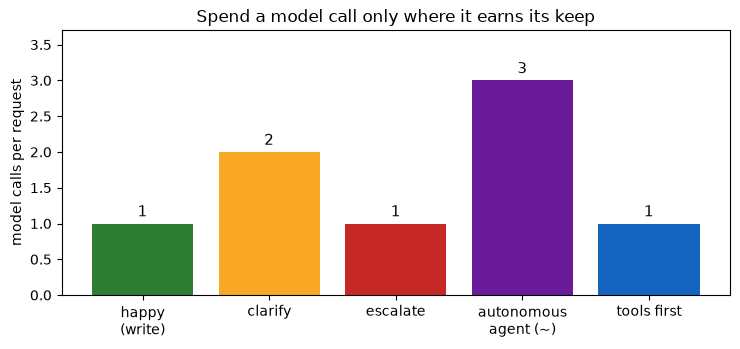

In [10]:
import matplotlib.pyplot as plt

labels = ["happy\n(write)", "clarify", "escalate", "autonomous\nagent (~)", "tools first"]
calls  = [1, 2, 1, 3, 1]
colors = ["#2e7d32", "#f9a825", "#c62828", "#6a1b9a", "#1565c0"]

plt.figure(figsize=(7.5, 3.6))
bars = plt.bar(labels, calls, color=colors)
for b, c in zip(bars, calls):
    plt.text(b.get_x() + b.get_width() / 2, c + 0.05, str(c), ha="center", va="bottom", fontsize=11)
plt.ylabel("model calls per request")
plt.title("Spend a model call only where it earns its keep")
plt.ylim(0, 3.7)
plt.tight_layout()
plt.show()

## Decision matrices

**Which orchestration pattern?**

| Pattern | Control | Deterministic | Observability | Model spend | Reach for it when | Avoid when |
|---|---|---|---|---|---|---|
| Heuristic + plain Python | total | yes | your logs | lowest | rules cover most traffic | logic is genuinely fuzzy |
| Agents as tools | high | mostly | per-tool logs | medium | one lead delegates to specialists | steps need a fixed audited order |
| Graph | high | yes | built-in trace | medium | approvals, quality gates, branches, parallel steps | a two-line if/else would do |
| Swarm | low | no | debug logs | highest | the sequence cannot be known upfront | you need repeatable order |

**Rule, tool, or model?** Pick the cheapest mechanism that fits.

| Mechanism | Use when | Cost | Main risk |
|---|---|---|---|
| Rule (regex, lookup, threshold) | the answer is deterministic | near zero | brittle if inputs drift |
| Deterministic tool | you need external data or a side effect | cheap | integration failure |
| LLM call | fuzzy language coming in or going out | highest | latency, spend, hallucination |

```mermaid
flowchart LR
    T[Sub-task] --> R{A rule can decide it?}
    R -->|yes| RULE[Use a rule]
    R -->|no| D{Needs data or an action?}
    D -->|yes| TOOL[Call a deterministic tool]
    D -->|no| L[Spend one LLM call]
```

## Frameworks worth keeping

**The four homes.** Every step in an agent system routes to one of these. If any is missing, that is your next production incident.

- **Proceed**: inputs are clean, do the work.
- **Recover**: something is missing but fixable, ask one question.
- **Escalate**: out of scope or policy, hand to a human, deterministically.
- **Fail safe**: an exception, degrade to a safe message and log it.

**The rule to model ladder.** Try each rung; climb only when the cheaper one cannot answer.

`rule -> deterministic tool -> single LLM call -> autonomous agent -> multi-agent`

Skeptic checkpoints before you add a model call:

- If your escalation path is an LLM, who audits the handoff when it invents a ticket id?
- A Graph makes the flow visible; it does not make wrong routing right. `decide_route` still owns the logic.
- More agents means more loops to bound, more logs to read, and more places to hallucinate. What did the extra autonomy actually buy?

## Scoreboard

Solved code above should score 6 / 6.

In [11]:
score = 0; total = 0
def check(label, test):
    global score, total
    total += 1
    try:
        test(); score += 1; print("  PASS  " + label)
    except Exception as e:
        print("  FAIL  " + label + "  ->  " + (str(e) or type(e).__name__))

def _raise():
    raise RuntimeError("boom")

def t1():
    assert valid_pnr("JX48Q2") and valid_pnr("ABC123")
    assert not valid_pnr("FLIGHT") and not valid_pnr("123456")
    assert not valid_pnr("JX4Q") and not valid_pnr(None)

def t2():
    e = cheap_extract("Is my flight confirmed? PNR JX48Q2")
    assert e is not None and e.pnr == "JX48Q2" and e.intent == Intent.BOOKING_STATUS
    assert cheap_extract("My flight got cancelled, what now?") is None
    assert cheap_extract("I want a refund and it was cancelled, PNR JX48Q2") is None

def t3():
    mk = lambda **k: Extraction(**{"pnr": "JX48Q2", "intent": Intent.BOOKING_STATUS, "confidence": 0.95, **k})
    assert decide_route(mk(intent=Intent.OTHER)) == Route.ESCALATE
    assert decide_route(mk()) == Route.WRITE
    assert decide_route(mk(pnr=None)) == Route.CLARIFY
    assert decide_route(mk(ambiguity_reason="two bookings")) == Route.CLARIFY
    assert decide_route(mk(confidence=0.3)) == Route.CLARIFY

def t4():
    tr = []
    ok, v = guard("a", lambda: 42, tr)
    assert ok and v == 42 and tr[-1] == ("a", "ok")
    ok, v = guard("b", _raise, tr)
    assert (not ok) and v is None and "error" in tr[-1][1]

def t5():
    sW = MockState(Extraction(pnr="JX48Q2", intent=Intent.BOOKING_STATUS, confidence=0.95).model_dump_json())
    assert route_is(Route.WRITE)(sW) and not route_is(Route.CLARIFY)(sW) and not route_is(Route.ESCALATE)(sW)
    sBad = MockState("not json")
    assert route_is(Route.ESCALATE)(sBad) and not route_is(Route.WRITE)(sBad)

def t6():
    routes = {(s, d): r for s, d, r in WIRING}
    assert routes.get(("extract", "write")) == "write"
    assert routes.get(("extract", "clarify")) == "clarify"
    assert routes.get(("extract", "escalate")) == "escalate"
    assert ENTRY["node"] == "extract"
    assert graph is not None

for lbl, fn in [("TODO 1  valid_pnr", t1), ("TODO 2  cheap_extract", t2),
                ("TODO 3  decide_route", t3), ("TODO 4  guard", t4),
                ("TODO 5  route_is", t5), ("TODO 6  graph wired", t6)]:
    check(lbl, fn)

print("\nSCORE: " + str(score) + " / " + str(total))
print("All checks passed - nice work." if score == total else "Fix the FAILs above, then re-run this cell.")

  PASS  TODO 1  valid_pnr
  PASS  TODO 2  cheap_extract
  PASS  TODO 3  decide_route
  PASS  TODO 4  guard
  PASS  TODO 5  route_is
  PASS  TODO 6  graph wired

SCORE: 6 / 6
All checks passed - nice work.


## Recap and where this goes next

- Branch on validated structure, and give every outcome a home: proceed, recover, escalate, fail safe.
- Routing and escalation that can be rules should be rules. The model is the expensive part.
- Tools first, model last. Guard tools, bound loops, log the trace on every request.
- Pick the lightest orchestration that fits; climb the ladder only when the problem forces you.

To take this to production: replace the in-line escalation with a real ticket to a queue, read region and model id from config, run on an IAM role with least privilege on `bedrock:InvokeModel`, and emit route mix, escalation rate, and token counts to CloudWatch.

Next, **Demo 3** hosts one of these hardened agents on **AgentCore**.